# Template: Local Data Analysis

Analyzes a small synthetic sample of daily subway station ridership counts (`data/raw/sample_counts/data.csv`) to demonstrate the local-data-import pattern. Copy this folder as a starting point for a new analysis and swap in your own CSV.

In [1]:
from datetime import date
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from shared.plots.style import apply_theme, add_source_footnote

apply_theme()

## Load raw data

In [2]:
raw_path = Path("data/raw/sample_counts/data.csv")
df = pd.read_csv(raw_path, parse_dates=["date"])
df.head()

,date,station,boardings
0,2026-08-03,Times Sq-42 St,58210
1,2026-08-03,Grand Central-42 St,49875
2,2026-08-03,Union Sq-14 St,37640
3,2026-08-04,Times Sq-42 St,61120
4,2026-08-04,Grand Central-42 St,52310


## Process: weekly average boardings per station

In [3]:
df["week_start"] = df["date"].dt.to_period("W-SUN").dt.start_time

weekly = (
    df.groupby(["week_start", "station"], as_index=False)["boardings"]
    .mean()
    .rename(columns={"boardings": "avg_daily_boardings"})
)

processed_path = Path("data/processed/sample_counts/data.csv")
processed_path.parent.mkdir(parents=True, exist_ok=True)
weekly.to_csv(processed_path, index=False)
weekly

,week_start,station,avg_daily_boardings
0,2026-08-03,Grand Central-42 St,45397.857143
1,2026-08-03,Times Sq-42 St,55762.857143
2,2026-08-03,Union Sq-14 St,37070.000000
3,2026-08-10,Grand Central-42 St,45898.571429
4,2026-08-10,Times Sq-42 St,56490.000000
5,2026-08-10,Union Sq-14 St,37401.428571


## Chart

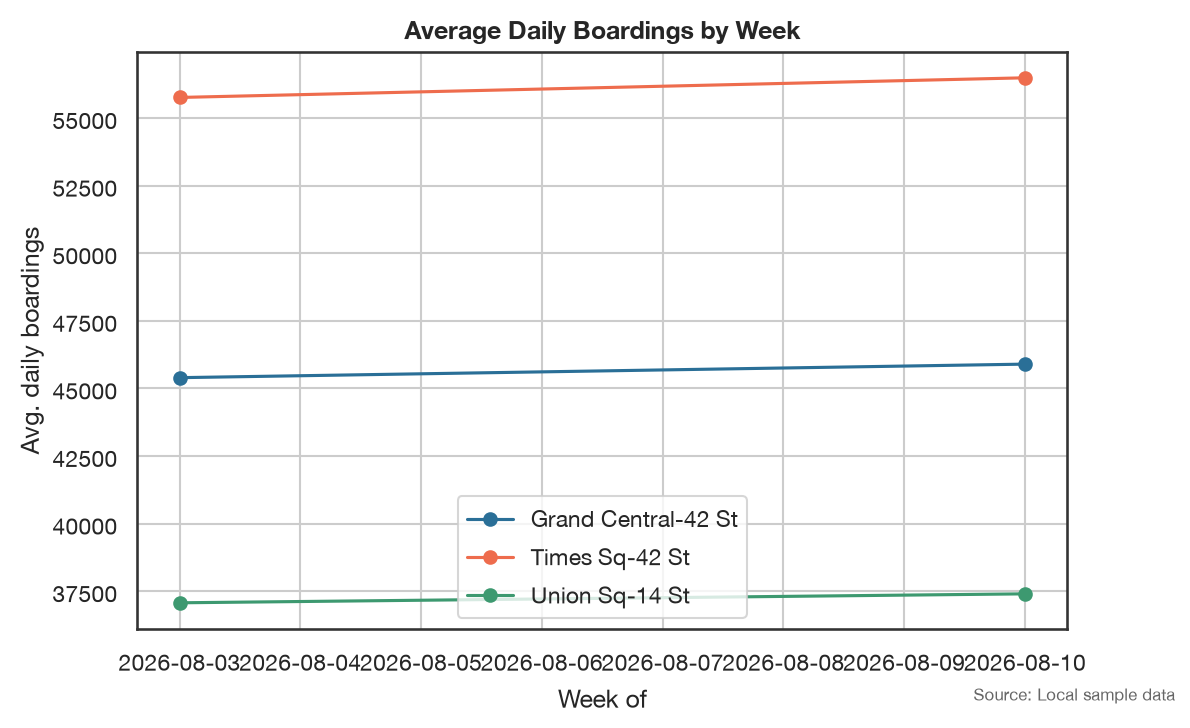

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for station, group in weekly.groupby("station"):
    ax.plot(group["week_start"], group["avg_daily_boardings"], marker="o", label=station)

ax.set_title("Average Daily Boardings by Week")
ax.set_xlabel("Week of")
ax.set_ylabel("Avg. daily boardings")
ax.legend()

add_source_footnote(fig, "Local sample data")

output_dir = Path(f"outputs/{date.today()}/charts")
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "avg_daily_boardings_by_week.png", bbox_inches="tight")
plt.show()